# Auditing a real model: *where* is it miscalibrated?

This is the diagnostic that sets KLCE apart. We train a recidivism-risk model on
the [COMPAS](https://github.com/propublica/compas-analysis) data using only
**criminal-history** features, then audit its local calibration with respect to
**protected attributes the model never saw** — age and race. This is the "auditor"
setting from the paper: the feature set used to *evaluate* trustworthiness (`X`)
differs from the one used to *train* the model (`Z`).

The **Local Calibration Bias (LCB)** diagnostic then localizes *where* and *for
whom* the model is miscalibrated.

> Requires `pandas` and `scikit-learn`. The COMPAS CSV is downloaded and cached
> on first run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kernel_calibration as kc
from kernel_calibration import plots as kcplots

## Load and prepare the data

In [2]:
df = kc.datasets.fetch_compas()
print(f"{len(df)} records after standard ProPublica filtering")

# Model features Z: criminal history + age/sex/charge — NOT race.
df = df.copy()
df["is_felony"] = (df["c_charge_degree"] == "F").astype(int)
df["is_male"] = (df["sex"] == "Male").astype(int)
df["is_black"] = (df["race"] == "African-American").astype(int)

Z_cols = [
    "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
    "age", "is_felony", "is_male",
]
Z = df[Z_cols].to_numpy(dtype=float)
y = df["two_year_recid"].to_numpy(dtype=float)

# Audit features X: age and race (a protected attribute the model did not train on).
X_audit = df[["age", "is_black"]].to_numpy(dtype=float)

6172 records after standard ProPublica filtering


## Train a risk model on criminal history

In [3]:
(Z_tr, Z_te, y_tr, y_te, Xa_tr, Xa_te, idx_tr, idx_te) = train_test_split(
    Z, y, X_audit, np.arange(len(df)), test_size=0.4, random_state=0, stratify=y
)
scaler = StandardScaler().fit(Z_tr)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(Z_tr), y_tr)
f_te = clf.predict_proba(scaler.transform(Z_te))[:, 1]
print(f"test set: {len(y_te)} defendants, base recidivism rate = {y_te.mean():.3f}")

test set: 2469 defendants, base recidivism rate = 0.455


## Is it locally calibrated with respect to age and race?

In [4]:
pw, xw = kc.select_bandwidths(Xa_te, f_te)
stat, pval = kc.KLCE_test(Xa_te, y_te, f_te, pw, 500, key=0, x_kernel_width=xw)
print(f"KLCE^2 = {float(stat):.5f}   p-value = {float(pval):.4f}")
print(f"ECE (global) = {kc.expected_calibration_error(y_te, f_te):.4f}")
print("verdict:", "NOT locally calibrated w.r.t. age & race"
      if float(pval) < 0.05 else "no evidence of local miscalibration")

KLCE^2 = 0.00019   p-value = 0.0040
ECE (global) = 0.0317
verdict: NOT locally calibrated w.r.t. age & race


## Localize it: LCB by age, split by race

We evaluate the local calibration bias at each test defendant, then look at how it
varies with age separately for Black and non-Black defendants. Positive bias means
the model *under*-predicts recidivism there; negative means it *over*-predicts.

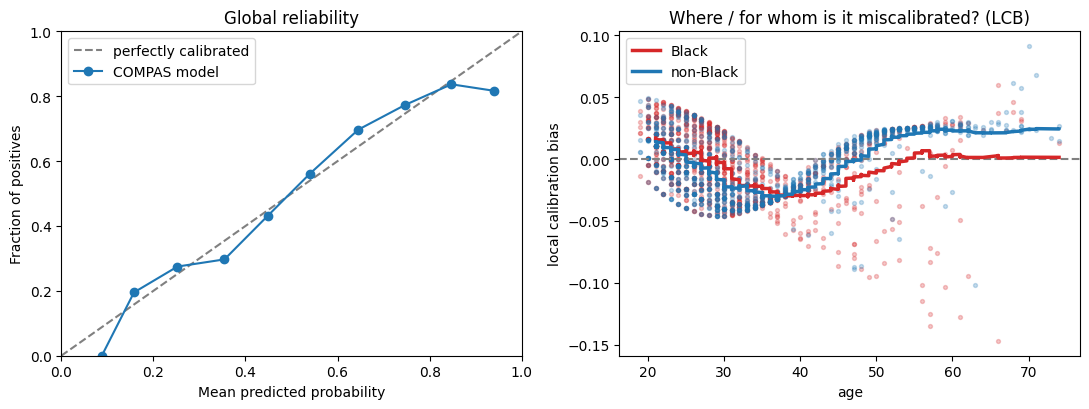

In [5]:
bias = np.asarray(kc.local_calibration_bias(Xa_te, y_te, f_te, pw, xw))
age = Xa_te[:, 0]
black = Xa_te[:, 1] == 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Overall reliability
kcplots.reliability_diagram(y_te, f_te, n_bins=10, ax=ax1, label="COMPAS model")
ax1.set_title("Global reliability")

# LCB vs age, by race, with binned trend lines
ax2.axhline(0.0, color="grey", ls="--")
for mask, name, color in [(black, "Black", "tab:red"),
                          (~black, "non-Black", "tab:blue")]:
    ax2.scatter(age[mask], bias[mask], s=8, alpha=0.25, color=color)
    order = np.argsort(age[mask])
    a_sorted = age[mask][order]
    b_sorted = bias[mask][order]
    # simple moving average as a trend line
    k = max(5, len(b_sorted) // 15)
    trend = np.convolve(b_sorted, np.ones(k) / k, mode="valid")
    ax2.plot(a_sorted[k - 1:], trend, color=color, lw=2.5, label=name)
ax2.set_xlabel("age")
ax2.set_ylabel("local calibration bias")
ax2.set_title("Where / for whom is it miscalibrated? (LCB)")
ax2.legend()
fig.tight_layout()
plt.show()

## Reading the diagnostic

The global reliability diagram and a single ECE number say the model is "roughly
calibrated." The LCB diagnostic tells a richer story: it exposes how the
calibration bias varies with **age** and differs between demographic **groups** —
exactly the kind of hidden, group-dependent miscalibration that motivates the
I-trustworthiness framework. An auditor can point to *which* defendants the risk
scores are systematically off for, rather than only whether the model is
calibrated on average.

> Numbers depend on the train/test split and are illustrative of the workflow,
> not a definitive audit of COMPAS.